In [ ]:
import os
import pandas as pd
# use polars when using very large dataframes as polars is faster than pandas
import polars as pl

# use pickle to save and load data objects (when saving a df using pickle, you save more information)
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# With the ic() method you can print something that is between the brackets and automatically also print its name
from icecream import ic


## Load the holidays, transactions and oil datasets and show basic info for each

In [ ]:
# Read the Parquet file using Pandas
# df = pd.read_parquet("C:/Users/jasmi/Documents/2025_Data_analyse/2025_03_Group_project_Supermarket/Data/data/history-per-year.parquet")

# print("The columns names are:", df.columns)
# print(f'the number of columns is {len(df.columns)}')

# Read the Parquet files
holidays = pd.read_parquet("C:/Users/jasmi/Documents/2025_Data_analyse/2025_03_Group_project_Supermarket/Data/data/holidays_events.parquet")
transactions = pd.read_parquet("C:/Users/jasmi/Documents/2025_Data_analyse/2025_03_Group_project_Supermarket/Data/data/transactions.parquet")
oil = pd.read_parquet("C:/Users/jasmi/Documents/2025_Data_analyse/2025_03_Group_project_Supermarket/Data/data/oil.parquet")
items = pd.read_parquet("C:/Users/jasmi/Documents/2025_Data_analyse/2025_03_Group_project_Supermarket/Data/data/items.parquet")
stores = pd.read_parquet("C:/Users/jasmi/Documents/2025_Data_analyse/2025_03_Group_project_Supermarket/Data/data/stores.parquet")
extra_data = {'holidays': holidays, 'transactions': transactions, 'oil': oil, 'items': items, 'stores': stores}


# Collect the DataFrame
for name, df in extra_data.items():
    print(f"\n📁 Dataset: {name.upper()}")
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print("\n🔹 Data Types & Non-Null Counts:")
    print(df.info())
    print(df.head(5))
    print("\n🔹 Descriptive Statistics:")
    print(df.describe(include='all'))
    print("\n🔹 Missing Values:")
    print(df.isnull().sum())
    print("\n🔹 Duplicate Rows:", df.duplicated().sum())
    print("-" * 80)



## Load orig_df and merge with oil, holidays and transactions

In [ ]:
# Load orig df
with open('../Data/data/dc-scoped-df.pkl', 'rb') as pickle_file:
    dc_scoped_df = pickle.load(pickle_file)
df_orig = dc_scoped_df['df_pd_pandas']

# Create 'date' columns in datetime format
df_orig['date'] = pd.to_datetime(df_orig['month'].astype(str) + '-01') + pd.to_timedelta(df_orig['day'] - 1, unit='d')
holidays['date'] = pd.to_datetime(holidays['date'])
transactions['date'] = pd.to_datetime(transactions['date'])
oil['date'] = pd.to_datetime(oil['date'])

# try to reduce processing times
df_orig = df_orig.astype({'store_nbr': 'category'}) # Convert categorical columns to category type for efficiency
holidays = holidays.astype({'locale': 'category'}) # Convert categorical columns to category type for efficiency
holidays = holidays[['date', 'locale_name']]  # Keep only essential columns

# Merge oil prices (by date) in chuncks
chunk_size = 100000  # Adjust based on your system
merged_chunks = []
for chunk in np.array_split(df_orig, len(df_orig) // chunk_size):
    merged_chunk = chunk.merge(oil, on='date', how='left')
    merged_chunks.append(merged_chunk)
df_full = pd.concat(merged_chunks)

# Merge transactions data in chuncks
chunk_size = 100000  # Adjust based on your system
merged_chunks = []
for chunk in np.array_split(df_orig, len(df_orig) // chunk_size):
    merged_chunk = chunk.merge(transactions, on=['store_nbr', 'date'], how='left')
    merged_chunks.append(merged_chunk)
df_full = pd.concat(merged_chunks)

# Merge holiday events (may duplicate rows if holidays vary by locale)
chunk_size = 100000  # Adjust based on your system
merged_chunks = []
for chunk in np.array_split(df_orig, len(df_orig) // chunk_size):
    merged_chunk = chunk.merge(holidays, on='date', how='left', suffixes=('', '_holiday'))
    merged_chunks.append(merged_chunk)
df_full = pd.concat(merged_chunks)


## Quick relationship Exploration 

In [ ]:
# Correlation heatmap of numerical features:
plt.figure(figsize=(10, 6))
sns.heatmap(df_full.select_dtypes(include='number').corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Numeric Features")
plt.show()

# Example: Average Sales by Store Type
avg_sales_by_store_type = df_full.groupby('type')['unit_sales'].mean()
print(avg_sales_by_store_type)

# Example: Sales Over Time
df_full.groupby('date')['unit_sales'].sum().plot(title="Total Sales Over Time", figsize=(12, 4))
plt.ylabel("Unit Sales")
plt.show()


## Exploratory Data Analysis (EDA) Bot — Python Script 

### 1. General overview

In [ ]:
sns.set(style="whitegrid")
print("🔍 Dataset Shape:", df_full.shape)
print("📋 Columns:\n", df_full.columns)
print("\n🧾 Basic Info:")
print(df_full.info())

print("\n📊 Summary Stats (Numerical):")
print(df_full.describe())


## Analyse the on promotion effect

In [ ]:
promo_df = df_orig[df_orig['onpromotion'].notna()]
promo_df['onpromotion'] = promo_df['onpromotion'].astype('bool')  # Convert to boolean
promo_df['unit_sales'] = promo_df['unit_sales'].astype('float32')  # Reduce memory footprint


# Mean unit_Sales for on/off promotions
promo_sales = promo_df.groupby('onpromotion')['unit_sales'].mean()
sns.boxplot(x=promo_df['onpromotion'], y=promo_df['unit_sales'])
plt.title("Unit Sales Distribution: Promoted vs. Non-Promoted")
plt.show()

promo_df.groupby(['date', 'onpromotion'])['unit_sales'].sum().unstack().plot(figsize=(12,5))
plt.title("Sales Trend: Promoted vs. Non-Promoted")
plt.show()

top_items = df_full[df_full['onpromotion'] == True]  # Filter only promoted items
top_items_count = top_items['item_nbr'].value_counts().head(10)  # Count occurrences and get top 10
print(top_items_count)

for item in top_items_count.index.tolist():
    df = promo_df[promo_df['item_nbr'] == item]
    df['onpromotion'] = df['onpromotion'].astype(str)  # Convert Boolean to String for plotting
    sns.boxplot(x=df['onpromotion'], y=df['unit_sales'])
    plt.title(f"Unit Sales Distribution: Promoted vs. Non-Promoted for item {item}")
    plt.show()
    df.groupby(['date', 'onpromotion'])['unit_sales'].sum().unstack().plot(figsize=(12,5))
    plt.title(f"Sales Trend: Promoted vs. Non-Promoted for item {item}")
    plt.show()


## Analyze the promotion effect at store_item level

C:\Users\jasmi\AppData\Local\Temp\ipykernel_12524\3042147735.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  promo_df['onpromotion'] = promo_df['onpromotion'].astype('bool')  # Convert to boolean
C:\Users\jasmi\AppData\Local\Temp\ipykernel_12524\3042147735.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  promo_df['unit_sales'] = promo_df['unit_sales'].astype('float32')  # Reduce memory footprint


item_nbr   store_nbr
1392260.0  44           575
1392261.0  3            566
1392260.0  45           564
Name: count, dtype: int64
Processing item_stpre: (1392260.0, 44)


C:\Users\jasmi\AppData\Local\Temp\ipykernel_12524\3042147735.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['onpromotion'] = df['onpromotion'].astype(str)  # Convert Boolean to String for plotting
c:\Users\jasmi\Documents\2025_Data_analyse\2025_03_Group_project_Supermarket\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\jasmi\Documents\2025_Data_analyse\2025_03_Group_project_Supermarket\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dty

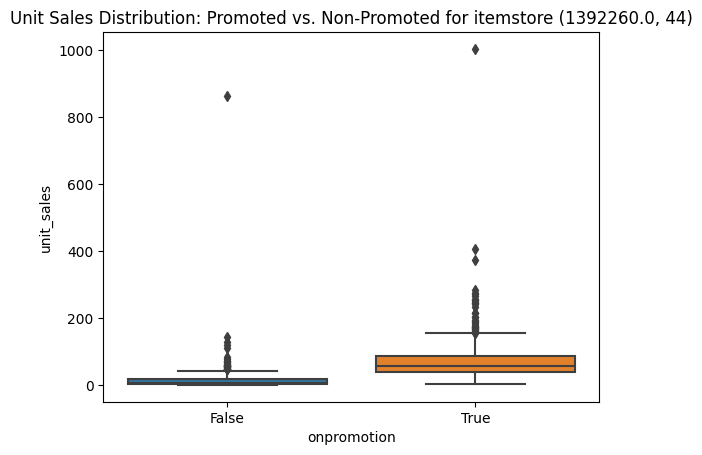

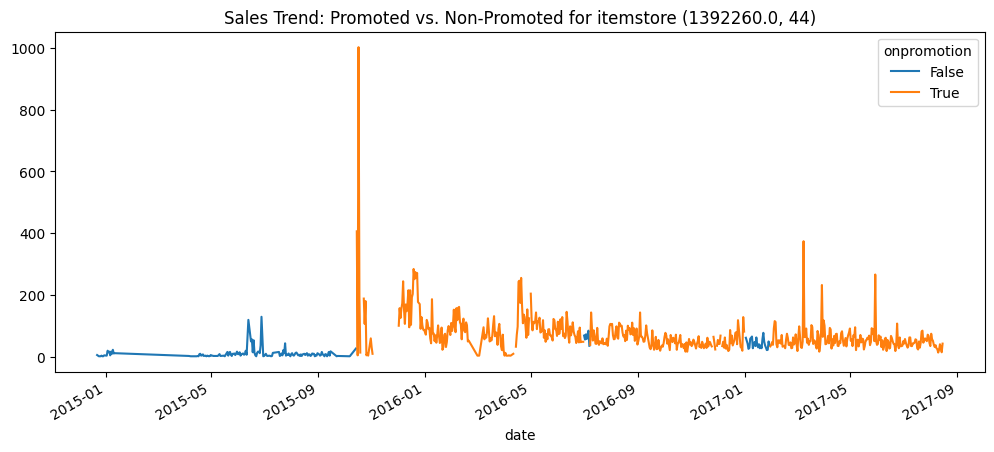

Processing item_stpre: (1392261.0, 3)


C:\Users\jasmi\AppData\Local\Temp\ipykernel_12524\3042147735.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['onpromotion'] = df['onpromotion'].astype(str)  # Convert Boolean to String for plotting
c:\Users\jasmi\Documents\2025_Data_analyse\2025_03_Group_project_Supermarket\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\jasmi\Documents\2025_Data_analyse\2025_03_Group_project_Supermarket\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dty

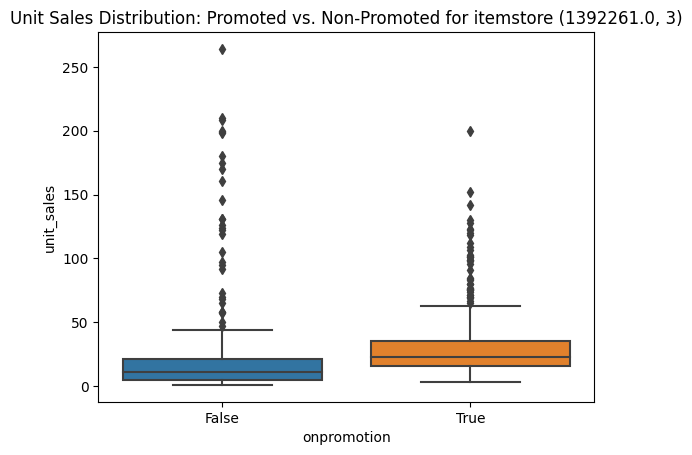

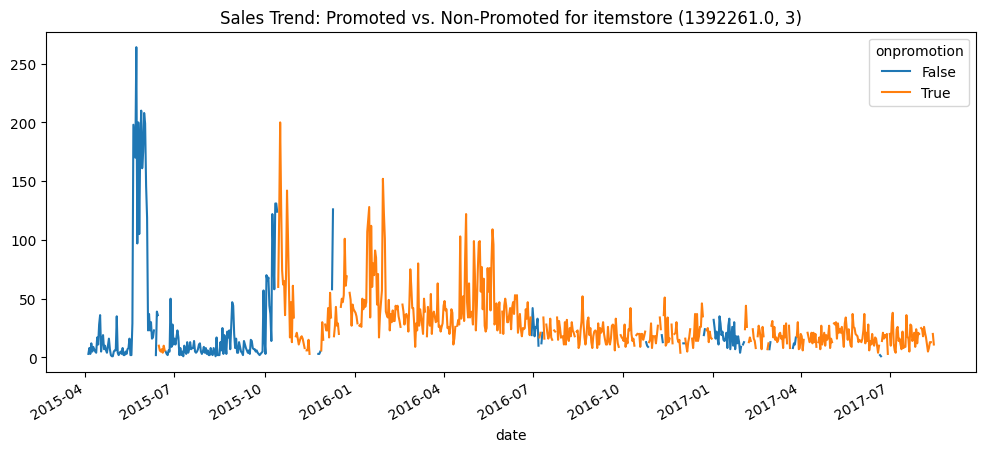

Processing item_stpre: (1392260.0, 45)


C:\Users\jasmi\AppData\Local\Temp\ipykernel_12524\3042147735.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['onpromotion'] = df['onpromotion'].astype(str)  # Convert Boolean to String for plotting
c:\Users\jasmi\Documents\2025_Data_analyse\2025_03_Group_project_Supermarket\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\jasmi\Documents\2025_Data_analyse\2025_03_Group_project_Supermarket\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dty

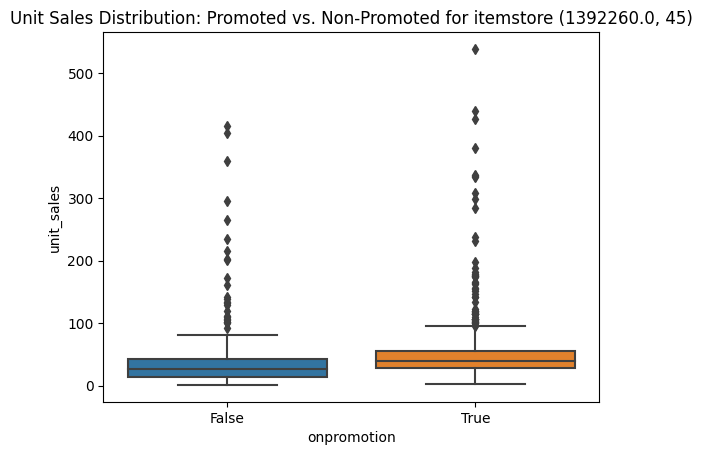

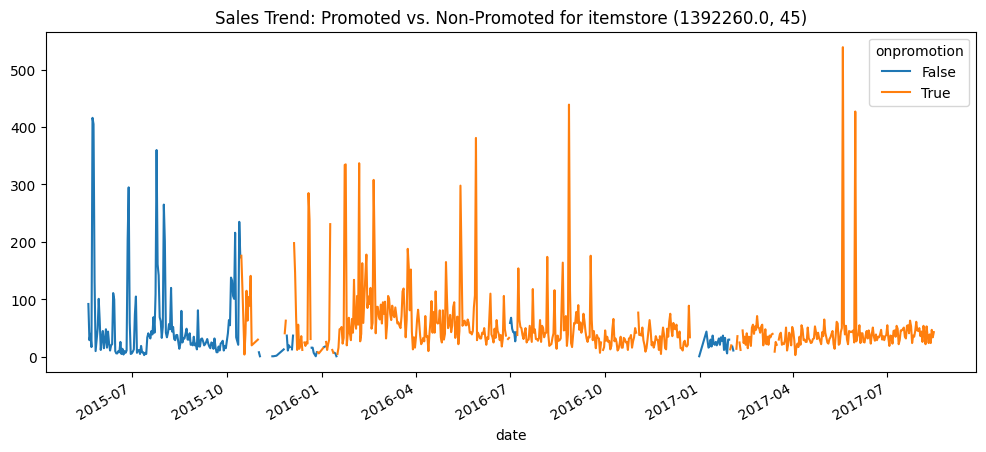

In [ ]:
import os
import pandas as pd
# use polars when using very large dataframes as polars is faster than pandas
import polars as pl

# use pickle to save and load data objects (when saving a df using pickle, you save more information)
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load orig df
with open('../Data/data/dc-scoped-df.pkl', 'rb') as pickle_file:
    dc_scoped_df = pickle.load(pickle_file)
df_orig = dc_scoped_df['df_pd_pandas']
df_orig['date'] = pd.to_datetime(df_orig['month'].astype(str) + '-01') + pd.to_timedelta(df_orig['day'] - 1, unit='d')

df_orig_short = df_orig[['item_nbr', 'store_nbr', 'onpromotion', 'unit_sales', 'date']]  # Keep essential columns
promo_df = df_orig_short[df_orig_short['onpromotion'].notna()]
promo_df['onpromotion'] = promo_df['onpromotion'].astype('bool')  # Convert to boolean
promo_df['unit_sales'] = promo_df['unit_sales'].astype('float32')  # Reduce memory footprint

top_items = df_orig_short[df_orig_short['onpromotion'] == True]  # Filter only promoted items
top_items_count = top_items[['item_nbr', 'store_nbr']].value_counts().head(5)  # Count occurrences and get top 5
print(top_items_count)

for itemstore in top_items_count.index.tolist()[:5]:  # Select only first 5 items
    print(f"Processing item_stpre: {itemstore}")

    # Perform operations with each item
    df = promo_df[(promo_df['item_nbr'] == itemstore[0]) & (promo_df['store_nbr'] == itemstore[1])]
    df['onpromotion'] = df['onpromotion'].astype(str)  # Convert Boolean to String for plotting
    sns.boxplot(x=df['onpromotion'], y=df['unit_sales'])
    plt.title(f"Unit Sales Distribution: Promoted vs. Non-Promoted for itemstore {itemstore}")
    plt.show()
    df.groupby(['date', 'onpromotion'])['unit_sales'].sum().unstack().plot(figsize=(12,5))
    plt.title(f"Sales Trend: Promoted vs. Non-Promoted for itemstore {itemstore}")
    plt.show()